<a href="https://colab.research.google.com/github/sandhya-s11/Sandhya-codeboosters-internship-2026/blob/main/Phase_01_Data_Engineering_Day_02_SQL_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All the lib are sucessfully loaded")
print(f"pandas version:{pd.__version__}")
print(f"Sqlite3 version:{sqlite3.version}")

All the lib are sucessfully loaded
pandas version:2.2.2
Sqlite3 version:2.6.0


In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
df = pd.read_csv('student_performance.csv')


print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows")
df.head(3)


Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [5]:
conn=sqlite3.connect('college.db')
#conn => our connecctio to db
#college.db => the file created in colab file sys. of already there opens it else created one
cursor=conn.cursor()
#cursor for sql execution tool.cursor is like a pen that write sql commands into db
df.to_sql(
    'students',  #name of the table to create in db
    conn,        #which bd connection to use
    if_exists='replace',
    index=False     #dont write dataframe row nums as a col
)
#to_sql helps to create 30 columns automatically
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"database 'college.db' created sucessfully")
print(f"table 'students' has {count} rows")

database 'college.db' created sucessfully
table 'students' has 30 rows


In [6]:
#inspect the table structure
#PRAGMA is a special SQL command
#table_info() shows the structure of the table

cursor.execute("PRAGMA table_info(students)")
columns_info =cursor.fetchall()
#fetchall() retrives ALL result rows(not just one)

print("Table structure of 'students'")
print(f"{'Column Name': <25} {'Data Type' : <12}")
#:<25 means left-align in 25 characters (for neat formatting)
print("-"*38)

for col in columns_info:
  #col is a tuple :(id,name,type,notnull,default,pk)
  print(f"{col[1]:<25}{col[2]:<12}")
  #col[1]=column name,col[2]=datatype


Table structure of 'students'
Column Name               Data Type   
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [7]:
def run_query(sql,description=""):
    if description:
        print(f"\n{'='*55}")
        print(f"{description}")
        print(f"{'='*55}")
    result = pd.read_sql_query(sql, conn)
    display(result)
    return result

print("Helper func. 'run query' defined successfully!")
print("usage: run_query(sql_string,description_label)")

Helper func. 'run query' defined successfully!
usage: run_query(sql_string,description_label)


In [8]:
query1 = """
  SELECT student_id, name, department, math_score, attendance_percentage
  FROM students
  LIMIT 10
"""

result1 = run_query(query1, "Basic SELECT")


Basic SELECT


,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


In [9]:
query2 = """
  SELECT student_id, name, department, math_score
  FROM students
  ORDER BY math_score DESC
  LIMIT 10
"""

result2 = run_query(query2, "ORDER BY + LIMIT")


ORDER BY + LIMIT


,student_id,name,department,math_score
0,1010,Ananya Das,Computer Science,95
1,1022,Tanvi Mehta,Computer Science,93
2,1005,Arjun Nair,Computer Science,92
3,1030,Akanksha Yadav,Computer Science,91
4,1018,Swati Kulkarni,Computer Science,90
5,1008,Divya Singh,Computer Science,88
6,1016,Ritu Agarwal,Electronics,87
7,1025,Amit Bose,Computer Science,86
8,1001,Aarav Sharma,Computer Science,85
9,1027,Gaurav Shukla,Computer Science,84


In [10]:
query3 = """
  SELECT student_id, name, department, math_score
  FROM students
  WHERE math_score > 80
  ORDER BY math_score DESC
  LIMIT 10
"""

result3 = run_query(query3, "WHERE filter")

display(result3)


WHERE filter


,student_id,name,department,math_score
0,1010,Ananya Das,Computer Science,95
1,1022,Tanvi Mehta,Computer Science,93
2,1005,Arjun Nair,Computer Science,92
3,1030,Akanksha Yadav,Computer Science,91
4,1018,Swati Kulkarni,Computer Science,90
5,1008,Divya Singh,Computer Science,88
6,1016,Ritu Agarwal,Electronics,87
7,1025,Amit Bose,Computer Science,86
8,1001,Aarav Sharma,Computer Science,85
9,1027,Gaurav Shukla,Computer Science,84


,student_id,name,department,math_score
0,1010,Ananya Das,Computer Science,95
1,1022,Tanvi Mehta,Computer Science,93
2,1005,Arjun Nair,Computer Science,92
3,1030,Akanksha Yadav,Computer Science,91
4,1018,Swati Kulkarni,Computer Science,90
5,1008,Divya Singh,Computer Science,88
6,1016,Ritu Agarwal,Electronics,87
7,1025,Amit Bose,Computer Science,86
8,1001,Aarav Sharma,Computer Science,85
9,1027,Gaurav Shukla,Computer Science,84


In [11]:
query4 = """
  SELECT student_id, name, department, math_score
  FROM students
  WHERE math_score > 80 AND department = 'Computer Science'
  ORDER BY math_score DESC
  LIMIT 10
"""

result4 = run_query(query4, "Multiple WHERE conditions")
display(result4)


Multiple WHERE conditions


,student_id,name,department,math_score
0,1010,Ananya Das,Computer Science,95
1,1022,Tanvi Mehta,Computer Science,93
2,1005,Arjun Nair,Computer Science,92
3,1030,Akanksha Yadav,Computer Science,91
4,1018,Swati Kulkarni,Computer Science,90
5,1008,Divya Singh,Computer Science,88
6,1025,Amit Bose,Computer Science,86
7,1001,Aarav Sharma,Computer Science,85
8,1027,Gaurav Shukla,Computer Science,84
9,1013,Suresh Rao,Computer Science,83


,student_id,name,department,math_score
0,1010,Ananya Das,Computer Science,95
1,1022,Tanvi Mehta,Computer Science,93
2,1005,Arjun Nair,Computer Science,92
3,1030,Akanksha Yadav,Computer Science,91
4,1018,Swati Kulkarni,Computer Science,90
5,1008,Divya Singh,Computer Science,88
6,1025,Amit Bose,Computer Science,86
7,1001,Aarav Sharma,Computer Science,85
8,1027,Gaurav Shukla,Computer Science,84
9,1013,Suresh Rao,Computer Science,83


In [12]:
query5="""
select
department,
count(*) as num_students,
round(avg(math_score),2) as avg_math_score,
round(avg(science_score),2) as avg_science_score,
round(avg(english_score),2) as avg_english_score,
round(avg(attendance_percentage),2) as avg_attendance
from students
group by department
order by avg_math_score desc
"""
result5 = run_query(query5,"Query : 5 Department-wise Average Scores(group by)")


Query : 5 Department-wise Average Scores(group by)


,department,num_students,avg_math_score,avg_science_score,avg_english_score,avg_attendance
0,Computer Science,13,85.62,84.46,80.85,90.69
1,Mechanical,6,71.00,76.50,70.50,83.50
2,Electronics,6,71.00,74.17,70.83,80.33
3,Civil,5,63.40,66.60,65.20,74.60


In [13]:
# Query 7
query7 = """
    SELECT
       gender,
       COUNT(*) AS num_students,
       ROUND(AVG(math_score), 2) AS avg_math_score,
       ROUND(AVG(attendance_percentage), 2) AS avg_attendance
    FROM students
    GROUP BY gender
"""

result7 = run_query(query7, "Query 7 : Gender-wise Student Analysis")


Query 7 : Gender-wise Student Analysis


,gender,num_students,avg_math_score,avg_attendance
0,Female,15,78.47,88.53
1,Male,15,73.67,80.47


In [14]:
query6 = """
    SELECT
       department,
       ROUND(AVG(math_score),2) AS avg_math,
       COUNT(*) AS students
    FROM students
    GROUP BY department
    HAVING AVG(math_score)>70
    ORDER BY avg_math DESC
"""

result6 = run_query(query6, "Query 6: Department with Average Math >70 ( HAVING)")


Query 6: Department with Average Math >70 ( HAVING)


,department,avg_math,students
0,Computer Science,85.62,13
1,Mechanical,71.00,6
2,Electronics,71.00,6


In [15]:
query8="""
select
name,
department,
math_score+science_score+english_score+programming_score as total_score
from students
order by total_score desc
limit 10
"""
result8 = run_query(query8,"Query : 8 Top 5 Students by Total Score")


Query : 8 Top 5 Students by Total Score


,name,department,total_score
0,Ananya Das,Computer Science,371
1,Tanvi Mehta,Computer Science,367
2,Akanksha Yadav,Computer Science,365
3,Arjun Nair,Computer Science,356
4,Divya Singh,Computer Science,356
5,Swati Kulkarni,Computer Science,354
6,Amit Bose,Computer Science,336
7,Suresh Rao,Computer Science,334
8,Nisha Kapoor,Computer Science,327
9,Aarav Sharma,Computer Science,326


In [16]:
departments_df = df[['department']].drop_duplicates().reset_index(drop=True)
departments_df['dept_code'] = departments_df.index + 101 # Assigning a simple department code

departments_df.to_sql(
    'departments',
    conn,
    if_exists='replace',
    index=False
)

print("Departments table created successfully!")

cursor.execute("PRAGMA table_info(departments)")
columns_info_dept = cursor.fetchall()
print("\nTable structure of 'departments':")
print(f"{'Column Name':<25} {'Data Type':<12}")
print("-" * 38)
for col in columns_info_dept:
  print(f"{col[1]:<25} {col[2]:<12}")

display(departments_df.head())

Departments table created successfully!

Table structure of 'departments':
Column Name               Data Type   
--------------------------------------
department                TEXT        
dept_code                 INTEGER     


,department,dept_code
0,Computer Science,101
1,Electronics,102
2,Mechanical,103
3,Civil,104


In [17]:
# Add dept_code to the students table
cursor.execute("ALTER TABLE students ADD COLUMN dept_code INTEGER")

# Update dept_code in students table based on department name
for index, row in departments_df.iterrows():
    cursor.execute("UPDATE students SET dept_code = ? WHERE department = ?", (row['dept_code'], row['department']))
conn.commit()

print("Added 'dept_code' to 'students' table and updated values.")

# Verify by showing a few rows with the new dept_code
verify_query = "SELECT student_id, name, department, dept_code FROM students LIMIT 5"
run_query(verify_query, "Students table with new dept_code")

Added 'dept_code' to 'students' table and updated values.

Students table with new dept_code


,student_id,name,department,dept_code
0,1001,Aarav Sharma,Computer Science,101
1,1002,Priya Patel,Computer Science,101
2,1003,Rohit Verma,Electronics,102
3,1004,Sneha Reddy,Mechanical,103
4,1005,Arjun Nair,Computer Science,101


,student_id,name,department,dept_code
0,1001,Aarav Sharma,Computer Science,101
1,1002,Priya Patel,Computer Science,101
2,1003,Rohit Verma,Electronics,102
3,1004,Sneha Reddy,Mechanical,103
4,1005,Arjun Nair,Computer Science,101


In [18]:
query_join = """
SELECT
s.name,
s.department,
d.dept_code
FROM students AS s
INNER JOIN departments AS d
ON s.dept_code = d.dept_code
ORDER BY s.math_score DESC
LIMIT 8
"""

result_join = run_query(query_join, "Join: Students with Department Details (INNER JOIN)")


Join: Students with Department Details (INNER JOIN)


,name,department,dept_code
0,Ananya Das,Computer Science,101
1,Tanvi Mehta,Computer Science,101
2,Arjun Nair,Computer Science,101
3,Akanksha Yadav,Computer Science,101
4,Swati Kulkarni,Computer Science,101
5,Divya Singh,Computer Science,101
6,Ritu Agarwal,Electronics,102
7,Amit Bose,Computer Science,101


In [19]:
query_join = """
SELECT
s.name,
s.department,
d.dept_code
FROM students AS s
INNER JOIN departments AS d
ON s.dept_code = d.dept_code
ORDER BY s.math_score DESC
LIMIT 8
"""

result_join = run_query(query_join, "Join: Students with Department Details (INNER JOIN)")


Join: Students with Department Details (INNER JOIN)


,name,department,dept_code
0,Ananya Das,Computer Science,101
1,Tanvi Mehta,Computer Science,101
2,Arjun Nair,Computer Science,101
3,Akanksha Yadav,Computer Science,101
4,Swati Kulkarni,Computer Science,101
5,Divya Singh,Computer Science,101
6,Ritu Agarwal,Electronics,102
7,Amit Bose,Computer Science,101


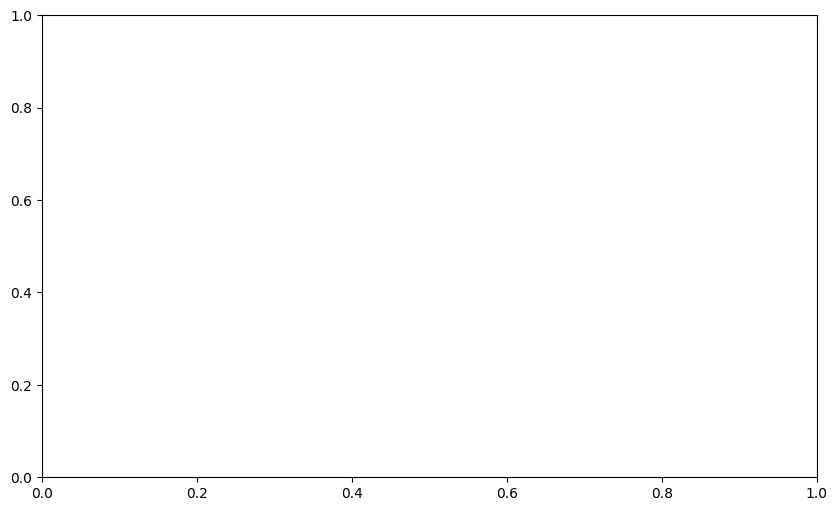

In [20]:
chart1_sql="""
SELECT department,ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data=pd.read_sql_query(chart1_sql, conn)
fig, ax=plt.subplots(figsize=(10,6))
bar_colours=['#4fc3f7','#00897B','#E67E22','#8E44AD']

Text(0.5, 1.0, 'Average Math Scores by Department')

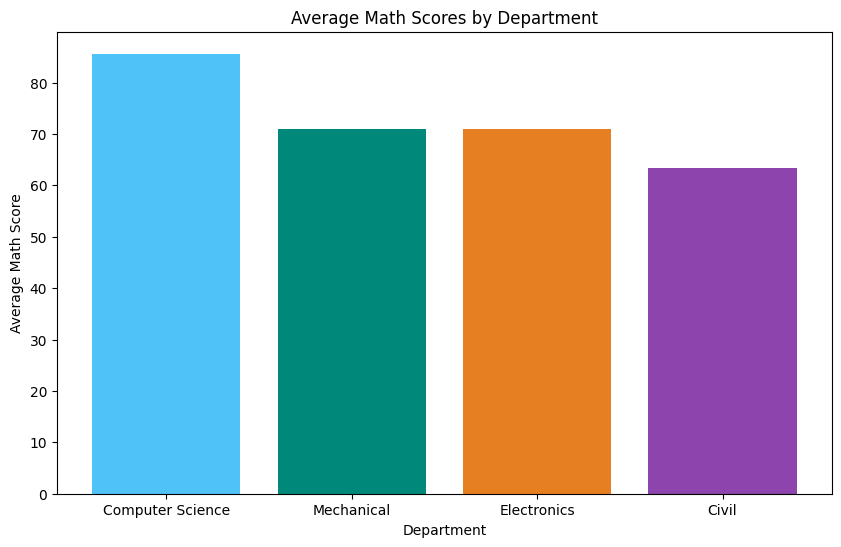

In [21]:
chart1_sql="""
SELECT department,ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data=pd.read_sql_query(chart1_sql, conn)
fig, ax=plt.subplots(figsize=(10,6))
bar_colours=['#4fc3f7','#00897B','#E67E22','#8E44AD']

ax.bar(chart1_data['department'],chart1_data['avg_math'],color=bar_colours)
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')
ax.set_title('Average Math Scores by Department')

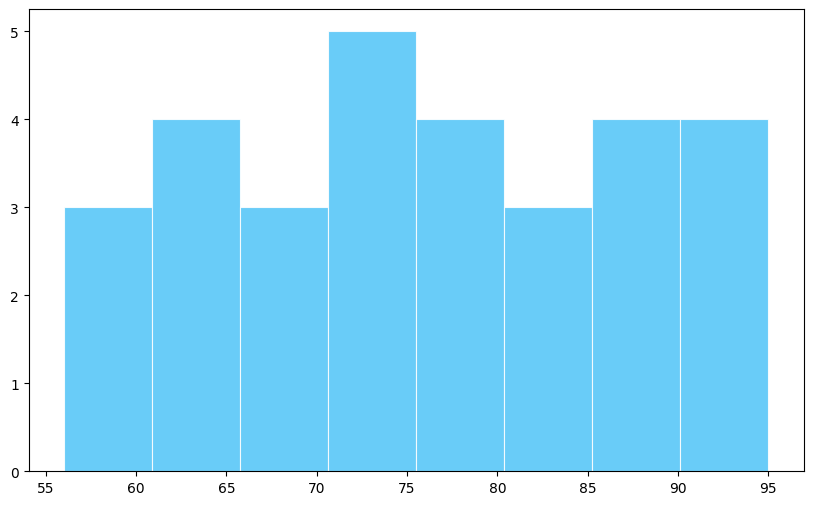

In [22]:
mat_score=df['math_score'].tolist()
fiog,ax=plt.subplots(figsize=(10,6))
n,bins,patches=ax.hist(
    mat_score,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)

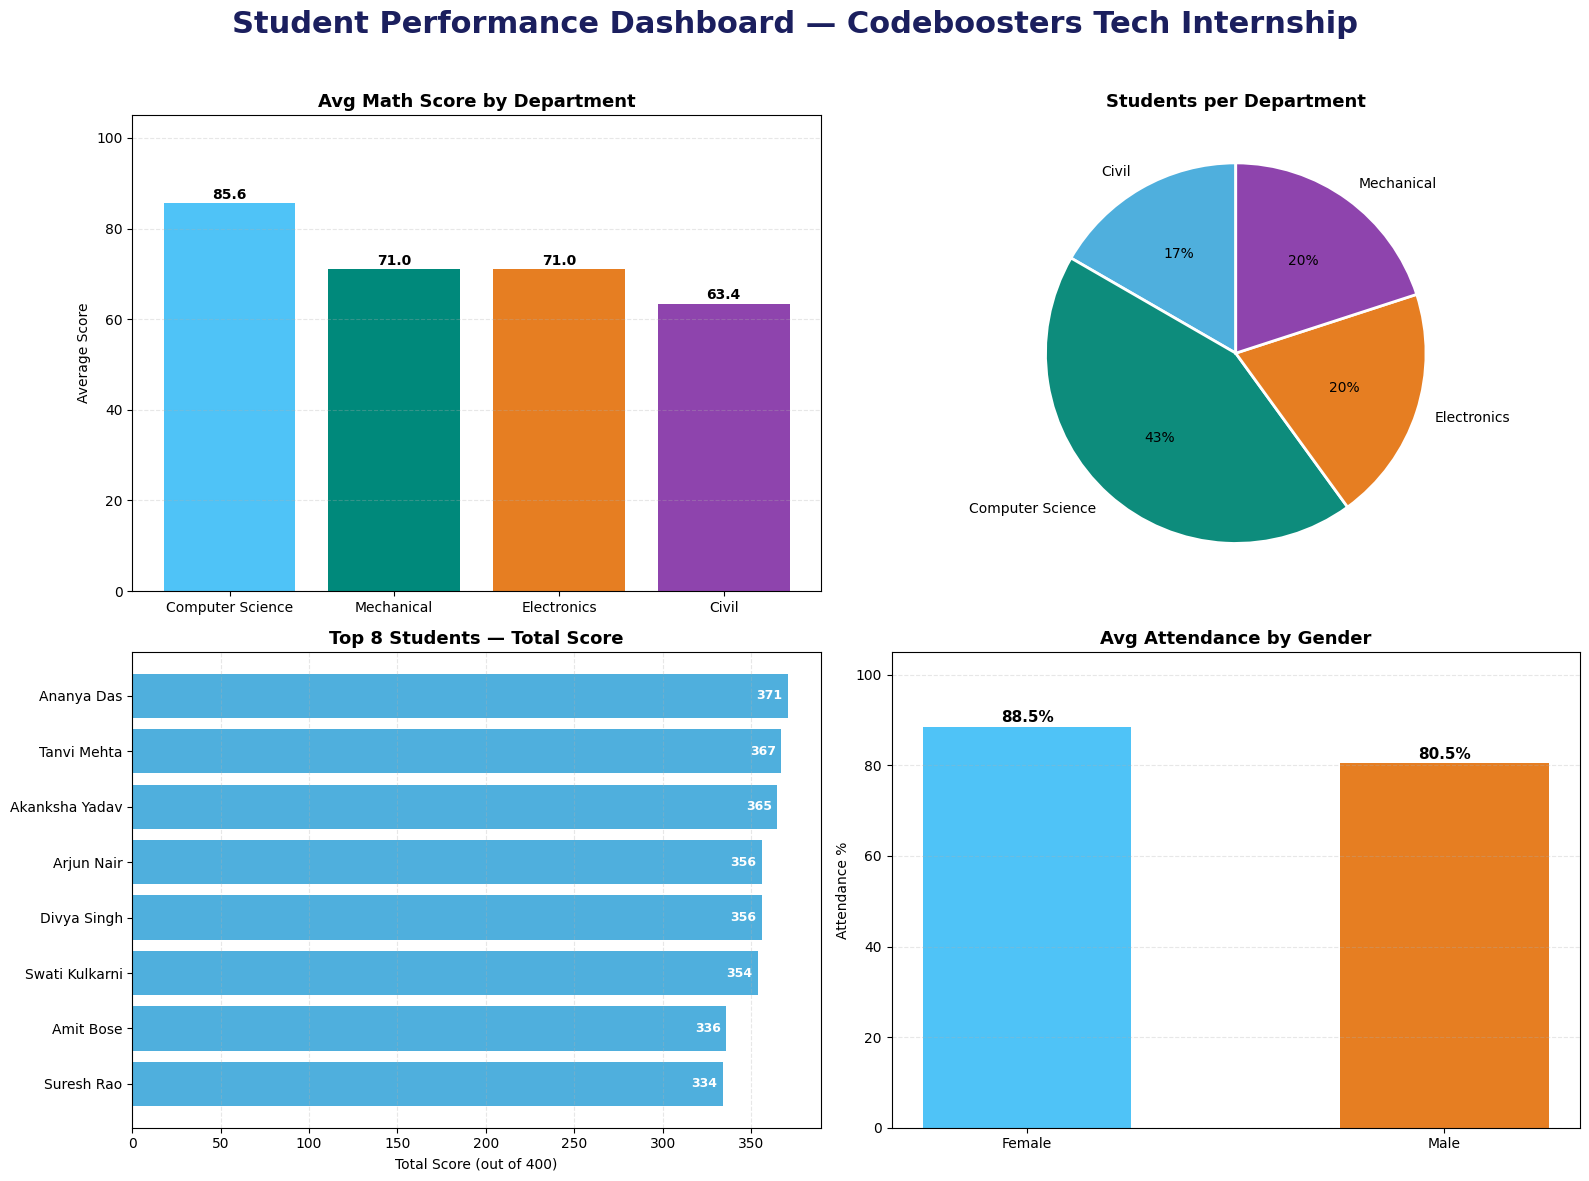

In [24]:
# QUERY 1: AVG MATH SCORE BY DEPARTMENT


chart1_sql = """
SELECT department,
       ROUND(AVG(math_score), 1) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


# QUERY 2: STUDENT COUNT PER DEPARTMENT


chart2_sql = """
SELECT department,
       COUNT(*) AS total_students
FROM students
GROUP BY department
"""

chart2_data = pd.read_sql_query(chart2_sql, conn)


# QUERY 3: TOP 8 STUDENTS BY TOTAL SCORE


chart3_sql = """
SELECT name,
       (math_score + science_score + english_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

chart3_data = pd.read_sql_query(chart3_sql, conn)


# QUERY 4: AVG ATTENDANCE BY GENDER


chart4_sql = """
SELECT gender,
       ROUND(AVG(attendance_percentage), 1) AS avg_attendance
FROM students
GROUP BY gender
"""

chart4_data = pd.read_sql_query(chart4_sql, conn)


# CREATE DASHBOARD


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PANEL 1 : AVG MATH SCORE BY DEPARTMENT


ax1 = axes[0, 0]

colors1 = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars1 = ax1.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=colors1
)

ax1.set_title("Avg Math Score by Department",
              fontsize=13,
              fontweight='bold')

ax1.set_ylabel("Average Score")
ax1.set_ylim(0, 105)


ax1.grid(axis='y', linestyle='--', alpha=0.3)


for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# PANEL 2 : PIE CHART


ax2 = axes[0, 1]

pie_colors = ['#4FAFDD', '#0D8C7C', '#E67E22', '#8E44AD']

ax2.pie(
    chart2_data['total_students'],
    labels=chart2_data['department'],
    autopct='%1.0f%%',
    startangle=90,
    colors=pie_colors,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    }
)

ax2.set_title("Students per Department",
              fontsize=13,
              fontweight='bold')


# PANEL 3 : TOP 8 STUDENTS


ax3 = axes[1, 0]

# Reverse order so topper appears at top
chart3_data = chart3_data[::-1]

bars3 = ax3.barh(
    chart3_data['name'],
    chart3_data['total_score'],
    color='#4FAFDD'
)

ax3.set_title("Top 8 Students — Total Score",
              fontsize=13,
              fontweight='bold')

ax3.set_xlabel("Total Score (out of 400)")

# Grid lines
ax3.grid(axis='x', linestyle='--', alpha=0.3)

# Score Labels Inside Bars
for bar in bars3:
    width = bar.get_width()
    ax3.text(
        width - 3,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        ha='right',
        color='white',
        fontsize=9,
        fontweight='bold'
    )


# PANEL 4 : ATTENDANCE BY GENDER


ax4 = axes[1, 1]

colors4 = ['#4FC3F7', '#E67E22']

bars4 = ax4.bar(
    chart4_data['gender'],
    chart4_data['avg_attendance'],
    color=colors4,
    width=0.5
)

ax4.set_title("Avg Attendance by Gender",
              fontsize=13,
              fontweight='bold')

ax4.set_ylabel("Attendance %")
ax4.set_ylim(0, 105)

# Grid lines
ax4.grid(axis='y', linestyle='--', alpha=0.3)

# Percentage Labels
for bar in bars4:
    height = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )


# MAIN DASHBOARD TITLE


fig.suptitle(
    "Student Performance Dashboard — Codeboosters Tech Internship",
    fontsize=22,
    fontweight='bold',
    color='#1B1F5E'
)


plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [26]:
query1 = """
SELECT ROUND(AVG(programming_score), 1) AS avg_programming_score
FROM students
WHERE gender = 'Female'
"""

result1 = pd.read_sql_query(query1, conn)

print(result1)

   avg_programming_score
0                   70.2


In [28]:
query_where = """
SELECT name, math_score
FROM students
WHERE math_score > 80
"""

result_where = pd.read_sql_query(query_where, conn)

print(result_where)

              name  math_score
0     Aarav Sharma          85
1       Arjun Nair          92
2      Divya Singh          88
3       Ananya Das          95
4       Suresh Rao          83
5     Ritu Agarwal          87
6   Swati Kulkarni          90
7      Tanvi Mehta          93
8        Amit Bose          86
9    Gaurav Shukla          84
10  Akanksha Yadav          91


In [30]:
query3 = """
SELECT department,
       ROUND(AVG(attendance_percentage), 1) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

result3 = pd.read_sql_query(query3, conn)

print(result3)


         department  avg_attendance
0  Computer Science            90.7


In [32]:
data = pd.read_sql_query(
    "SELECT * FROM students",
    conn
)

print(data)

    student_id            name  age  gender        department  semester  \
0         1001    Aarav Sharma   19    Male  Computer Science         2   
1         1002     Priya Patel   20  Female  Computer Science         2   
2         1003     Rohit Verma   19    Male       Electronics         2   
3         1004     Sneha Reddy   20  Female        Mechanical         2   
4         1005      Arjun Nair   19    Male  Computer Science         2   
5         1006     Meera Joshi   20  Female       Electronics         2   
6         1007     Kiran Kumar   21    Male             Civil         2   
7         1008     Divya Singh   19  Female  Computer Science         2   
8         1009    Rahul Mishra   20    Male        Mechanical         2   
9         1010      Ananya Das   19  Female  Computer Science         2   
10        1011     Vikram Iyer   20    Male       Electronics         2   
11        1012     Pooja Gupta   19  Female             Civil         2   
12        1013      Sures

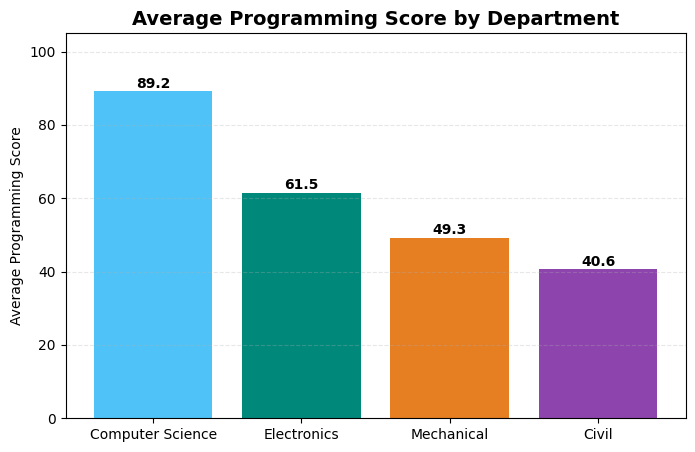

In [33]:
# =========================================
# AVG PROGRAMMING SCORE BY DEPARTMENT
# =========================================

chart1_sql = """
SELECT department,
       ROUND(AVG(programming_score), 1) AS avg_programming
FROM students
GROUP BY department
ORDER BY avg_programming DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

# --------------------------------
# BAR CHART
# --------------------------------

plt.figure(figsize=(8, 5))

colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

bars = plt.bar(
    chart1_data['department'],
    chart1_data['avg_programming'],
    color=colors
)

plt.title(
    "Average Programming Score by Department",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel("Average Programming Score")

plt.ylim(0, 105)

# Grid lines
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()